# 07b — 06b-style shared Reid and dePablo baseline

Reference static-context reconstruction and rollout

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import lss.latent.experiment as _latent_experiment
importlib.reload(_latent_experiment)
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, run_latent_experiment, seed_everything
from lss.latent.simulation import r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
REQUESTED_DEVICE = 'cuda'
DEVICE = resolve_device(REQUESTED_DEVICE)
print(f'Device: {DEVICE}')

Device: cuda


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 4654562
MODEL_KEY = 'AZ_frozen_AY_static_delta_h64_seed456_matched_split'
TRAIN_COUNTS = {'reid': 15, 'depablo_low_temp': 15, 'depablo_mixed_temp': 15}
VAL_PER_SOURCE = 15
TRAIN_FRAMES = 100
LATENT_DIM = 2
AE_TARGET_MODE = 'normalized_delta'
AE_MAX_EPOCHS = 30
AE_PATIENCE = 5
DYN_MAX_EPOCHS = 30
DYN_PATIENCE = 5
BATCH_GRAPHS = 512
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'07b_mixed_reid_depablo_lj_context_ablation'
OUTPUT.mkdir(parents=True, exist_ok=True)
DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'dePablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    # 'depablo_mixed_temp': {'label': 'dePablo mixed-T', 'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'},
}
for spec in DATASETS.values():
    assert spec['path'].is_file(), spec['path']
MIXTURE = [
    {'name': key, 'label': spec['label'], 'path': str(spec['path']),
     'train_count': TRAIN_COUNTS[key], 'val_count': VAL_PER_SOURCE, 'edge_vector_dim': 2}
    for key, spec in DATASETS.items()
]
source = {'dataset_name': 'mixed_reid_depablo', 'source_name': 'mixed_reid_depablo',
          'label': 'Reid + dePablo', 'path': MIXTURE[0]['path'], 'dataset_mixture': MIXTURE}
AE_CACHE = OUTPUT/'mixed4source_AY_evolving_box_06b_ae_recipe_seed456_reid_depablo_rollout.pt'
PROP_CACHE = OUTPUT/f'mixed4source_{MODEL_KEY}_rollout.pt'
assert AE_CACHE.is_file(), f'Missing corrected AE cache: {AE_CACHE}'
print({'train_per_source': TRAIN_COUNTS, 'val_per_source': VAL_PER_SOURCE,
       'latent_dim': LATENT_DIM, 'frames': TRAIN_FRAMES,
       'propagator': 'static context + current z → Δz (no motion history)'})

{'train_per_source': {'reid': 15, 'depablo_low_temp': 15, 'depablo_mixed_temp': 15}, 'val_per_source': 15, 'latent_dim': 2, 'frames': 100, 'propagator': 'static context + current z → Δz (no motion history)'}


In [3]:


prop_config = {
    'dataset_name': 'mixed_reid_depablo', 'split_seed': SEED, 'model_seed': SEED,
    'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': BATCH_GRAPHS, 'frame_skip': 1,
    'coordinate_normalization': 'position_normalization', 'train_frame_start_order': 0,
    'edge_mode': 'compact_stored', 'edge_feature_schema': 'compact_unique_edge_changes_v1',
    'static_context_use_physical_reference': True,
    'ae_config': {
        'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96, 'model': 'attention',
        'edge_feature_dim': 4, 'target_mode': AE_TARGET_MODE, 'node_feature_mode': 'normalized_delta',
        'max_train_frames_per_sim': TRAIN_FRAMES, 'val_frame_skip': 1, 'max_val_frames_per_sim': TRAIN_FRAMES,
        'max_epochs': AE_MAX_EPOCHS, 'patience': AE_PATIENCE, 'lr': 1e-4, 'weight_decay': 1e-5,
        'balance_sources': False, 'mix_sources': True,
    },
    'propagator_config': {
        'max_train_transitions_per_sim': TRAIN_FRAMES - 1, 'max_epochs': DYN_MAX_EPOCHS, 'patience': DYN_PATIENCE,
        'lr': 1e-4, 'weight_decay': 1e-5, 'hidden_size': 64,
        'objective': 'one_step', 'model': 'delta_mlp', 'loss': 'delta',
        'mix_sources': True, 'balance_sources': False,
        'train_trajectories_per_source': TRAIN_COUNTS,
        'val_trajectories_per_source': {key: VAL_PER_SOURCE for key in DATASETS},
        'use_static_context': True, 'context_pool': 'mean', 'context_dim': 16,
        'context_include_source_id': False, 'rollout_eval_every_epoch': True,
        'rollout_eval_horizons': [100], 'rollout_eval_sims_per_source': VAL_PER_SOURCE,
    },
    'pretrained_ae_cache_path': str(AE_CACHE),
    'pretrained_ae_skip_stat_fitting': True,
    'pretrained_ae_require_matching_normalizers': False,
    'should_rollout': True, 'should_train_propagator': True,
    'force_train': True, 'force_train_autoencoder': False,
    'cache_path': str(PROP_CACHE), 'cache_require_matching_config': True,
    'dataset_mixture': MIXTURE, 'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [25, 50, 75, 100], 'rollout_eval_splits': ['val', 'test'],
    'rollout_eval_max_sims_by_split': {}, 'rollout_final_eval_sims_per_source': 30,
}
assert prop_config['ae_config']['target_mode'] == AE_TARGET_MODE
seed_everything(SEED)
prop_result = run_latent_experiment(source, prop_config, device=DEVICE)
ae_result = prop_result
display(prop_result['split_info'])


=== Reid + dePablo ===
          source                                                                path  total  train  reserved_train_pool  val  test
            reid        /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     15                   15   15    72
depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     15                   15   15   170
source-mixed AE coverage: {'reid': {'trajectories': 15, 'frames': 1500}, 'depablo_low_temp': {'trajectories': 15, 'frames': 1500}}
autoencoder
loaded pretrained AE: /home/alexz/Documents/course_project/notebooks/results/07b_mixed_reid_depablo_lj_context_ablation/mixed4source_AY_evolving_box_06b_ae_recipe_seed456_reid_depablo_rollout.pt


ValueError: Per-source trajectory limits did not match loaded sources: ['depablo_mixed_temp']

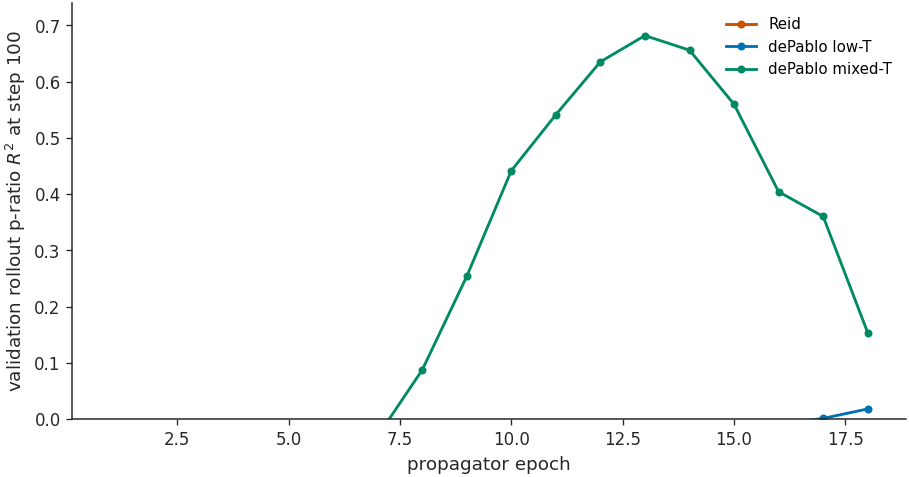

In [ ]:
rollout_epoch_r2_columns = {
    source_key: f'val_rollout_source_{source_key}_p_ratio_r2'
    for source_key in DATASETS
}
rollout_epoch_r2 = prop_result['dyn_history'].reindex(
    columns=['epoch', *rollout_epoch_r2_columns.values()]
).copy()
rollout_epoch_r2.to_csv(OUTPUT/f'{MODEL_KEY}_val_rollout_p_ratio_r2_by_epoch.csv', index=False)
fig, ax = plt.subplots(figsize=(7.6, 4.0), constrained_layout=True)
for source_key, column in rollout_epoch_r2_columns.items():
    rows = rollout_epoch_r2[['epoch', column]].dropna()
    if not rows.empty:
        ax.plot(rows.epoch, rows[column], marker='o', markersize=3.8, linewidth=1.7,
                color=dataset_color(source_key), label=DATASETS[source_key]['label'])
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
ax.set_ylim(bottom=0)
style_axes(ax, xlabel='propagator epoch', ylabel='validation rollout p-ratio $R^2$ at step 100', legend=True)
plt.show()

/home/alexz/Documents/course_project/src/lss/plotting.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="best")


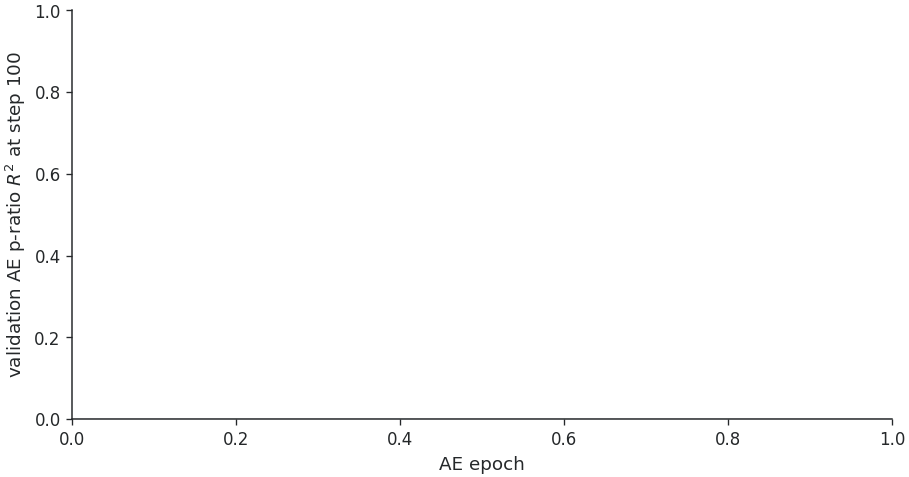

,source,n,ae_p_ratio_r2
0,Reid,15,0.934
1,dePablo low-T,15,0.909
2,dePablo mixed-T,15,0.712


In [ ]:
ae_epoch_r2_columns = {
    source_key: f'val_ae_source_{source_key}_p_ratio_r2_step_100'
    for source_key in DATASETS
}
ae_epoch_r2 = ae_result['ae_history'].reindex(columns=['epoch', *ae_epoch_r2_columns.values()]).copy()
ae_epoch_r2.to_csv(OUTPUT/f'{MODEL_KEY}_val_ae_p_ratio_r2_by_epoch.csv', index=False)
fig, ax = plt.subplots(figsize=(7.6, 4.0), constrained_layout=True)
for source_key, column in ae_epoch_r2_columns.items():
    rows = ae_epoch_r2[['epoch', column]].dropna()
    if not rows.empty:
        ax.plot(rows.epoch, rows[column], marker='o', markersize=4, linewidth=1.7, color=dataset_color(source_key), label=DATASETS[source_key]['label'])
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
style_axes(ax, xlabel='AE epoch', ylabel='validation AE p-ratio $R^2$ at step 100', legend=True)
plt.show()

ae_rows, _ = evaluate_autoencoder_reconstruction_horizons(
    ae_result['ae'], ae_result['val_data'], cfg=ae_result['params'], normalizers=ae_result['normalizers'],
    dataset=ae_result['label'], split_name='val', rollout_steps=[100], device=DEVICE,
)
ae_rows = ae_rows.query('rollout_steps == 100').copy()
ae_summary = []
for source_key, spec in DATASETS.items():
    rows = ae_rows.loc[ae_rows.source == source_key]
    ae_summary.append({'source': spec['label'], 'n': len(rows),
        'ae_p_ratio_r2': r2_score(rows.true_p_ratio, rows.pred_p_ratio) if len(rows) > 1 else np.nan})
ae_summary = pd.DataFrame(ae_summary)
display(ae_summary.round(3))

In [ ]:
print(f'Frozen AE: {AE_CACHE}')
print(f'Static Δz propagator cache: {PROP_CACHE}')

Frozen AE: /home/alexz/Documents/course_project/notebooks/results/07b_mixed_reid_depablo_lj_context_ablation/mixed4source_AY_evolving_box_06b_ae_recipe_seed456_reid_depablo_rollout.pt
Static Δz propagator cache: /home/alexz/Documents/course_project/notebooks/results/07b_mixed_reid_depablo_lj_context_ablation/mixed4source_AZ_frozen_AY_static_delta_h64_seed456_matched_split_rollout.pt


In [ ]:
val_rollout_rows = prop_result['rollout_rows'].query("split == 'val' and rollout_steps == 100").copy()
test_rollout_rows = prop_result['rollout_rows'].query("split == 'test' and rollout_steps == 100").copy()
rollout_summary = []
for source_key, spec in DATASETS.items():
    val_rows = val_rollout_rows.loc[val_rollout_rows.source == source_key]
    test_rows = test_rollout_rows.loc[test_rollout_rows.source == source_key]
    rollout_summary.append({'source': spec['label'], 'val_n': len(val_rows),
        'rollout_p_ratio_r2': r2_score(val_rows.true_p_ratio, val_rows.pred_p_ratio) if len(val_rows) > 1 else np.nan,
        'test_n': len(test_rows),
        'test_rollout_p_ratio_r2': r2_score(test_rows.true_p_ratio, test_rows.pred_p_ratio) if len(test_rows) > 1 else np.nan})
rollout_summary = pd.DataFrame(rollout_summary)
summary = ae_summary.rename(columns={'n': 'val_n'}).merge(rollout_summary, on=['source', 'val_n'], how='outer')
display(summary.round(3))
summary.to_csv(OUTPUT/f'{MODEL_KEY}_val_step100_ae_and_rollout_p_ratio_r2.csv', index=False)

,source,val_n,ae_p_ratio_r2,rollout_p_ratio_r2,test_n,test_rollout_p_ratio_r2
0,Reid,15,0.934,-0.047,30,-0.180
1,dePablo low-T,15,0.909,-0.049,30,-0.312
2,dePablo mixed-T,15,0.712,0.654,30,0.580


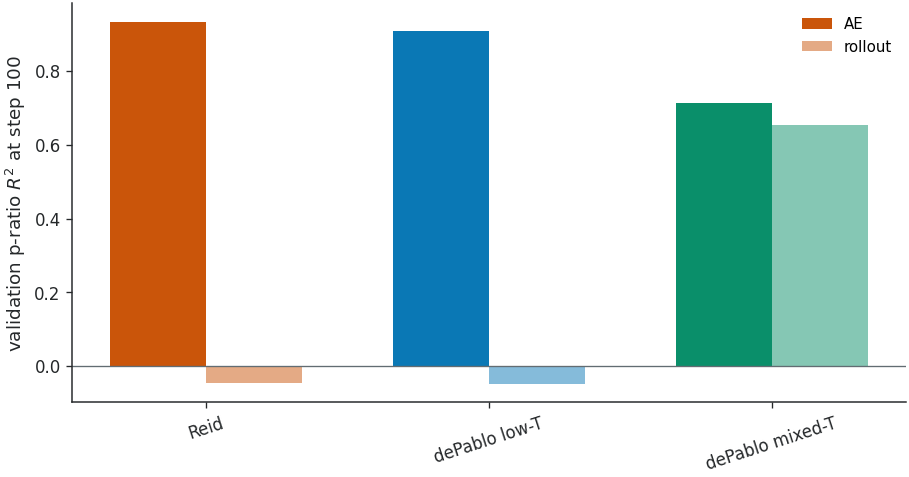

In [ ]:
fig, ax = plt.subplots(figsize=(7.6, 4.0), constrained_layout=True)
positions = np.arange(len(DATASETS))
for offset, column, label, alpha in [(-.17, 'ae_p_ratio_r2', 'AE', .96), (.17, 'rollout_p_ratio_r2', 'rollout', .48)]:
    ax.bar(positions + offset, summary[column], width=.34, color=[dataset_color(key) for key in DATASETS], alpha=alpha, label=label)
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
ax.set_xticks(positions, summary.source, rotation=18)
style_axes(ax, xlabel='', ylabel='validation p-ratio $R^2$ at step 100', legend=True)
plt.show()